In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_excel("all_data.xlsx") 
df['Quarter'] = pd.to_datetime(df['Quarter'])

In [3]:
# from scipy.stats import mstats

# # Колонки для winsorize (всё кроме ID, дат, таргетов, макры)
# skip = ['BANK_ID', 'Quarter', 'target', 
#         'target_8q_window', 'target_4q_window', 
#         'target_8q_point', 'target_4q_point',
#         'rgdp_yoy', 'cpi_y', 'income', 'USD_KZT_qoq']

# feature_cols = [c for c in df.columns if c not in skip]

# for col in feature_cols:
#     df[col] = mstats.winsorize(df[col], limits=[0.01, 0.01])

In [4]:
feature_cols = [c for c in df.columns if c not in [
    'BANK_ID', 'Quarter', 'target',
    'target_8q_window', 'target_4q_window',
    'target_8q_point', 'target_4q_point']]

stats = df[feature_cols].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
stats.columns = ['N', 'Среднее', 'Ст.откл.', 'Мин.', 'Медиана', 'Макс.']
stats['N'] = stats['N'].astype(int)

In [5]:
pd.DataFrame(stats.round(4))

,N,Среднее,Ст.откл.,Мин.,Медиана,Макс.
Asset_growth,1191,0.0571,0.1623,-0.3191,0.0363,0.8252
Average_risk_weight,1191,0.7302,0.3109,0.0670,0.7962,1.3355
Capital buffer (CAR),1191,0.4177,0.4486,0.0950,0.2010,2.4650
Deposit_growth,1191,0.0711,0.2441,-0.4603,0.0395,1.2539
Demand Deposit Ratio,1191,0.4249,0.2655,0.0265,0.3423,0.9951
Earning assets to total,1191,0.8833,0.0931,0.5378,0.9000,0.9955
Liquidity ratio,1191,1.0793,1.9841,0.0173,0.3007,10.6463
Loan_growth,1191,0.0696,0.1997,-0.3793,0.0347,1.0915
Loans to deposits,1191,1.1862,1.2587,0.0096,0.9166,7.9214
Trading book assets,1191,0.1256,0.1228,0.0000,0.0984,0.6077


In [6]:
# df = df.drop(columns=['Pre-tax net income', 'Non-interest income'])

In [7]:
# df.to_excel("all_data.xlsx", index = False)

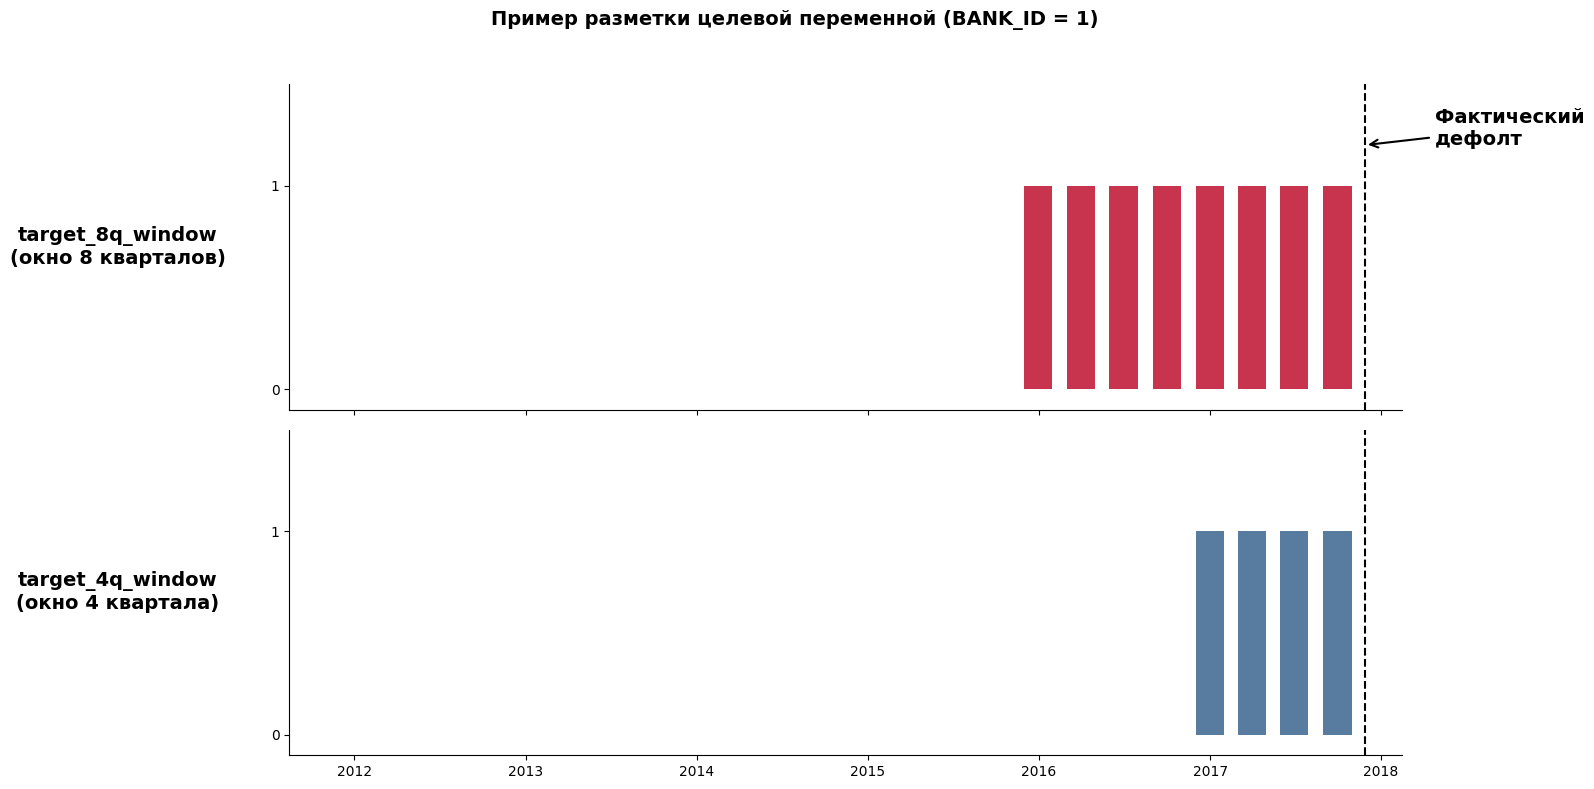

In [8]:
bank = df[df.BANK_ID == 1].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

target_info = [
    ('target_8q_window', 'target_8q_window\n(окно 8 кварталов)', '#BB0021'),
    ('target_4q_window', 'target_4q_window\n(окно 4 квартала)', '#2E5B88'),
    # ('target_8q_point',  'target_8q_point\n(точка за 8 кв.)',   '#808180'),
    # ('target_4q_point',  'target_4q_point\n(точка за 4 кв.)',   'skyblue'),
]

for i, (col, label, color) in enumerate(target_info):
    ax = axes[i]
    ax.bar(bank['Quarter'], bank[col], width=60, color=color, alpha=0.8)
    ax.set_ylabel(label, fontsize=14, fontweight='bold',
                  rotation=0, labelpad=110, va='center')
    ax.set_ylim(-0.1, 1.5)
    ax.set_yticks([0, 1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

distress_date = pd.Timestamp('2017-11-28')
for ax in axes:
    ax.axvline(x=distress_date, color='black', linestyle='--', linewidth=1.5)

axes[0].annotate('Фактический\nдефолт', xy=(distress_date, 1.2),
                 xytext=(50, 0), textcoords='offset points',
                 fontsize=14, fontweight='bold', color='black',
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].tick_params(axis='x', rotation=0, labelsize=10)

fig.suptitle('Пример разметки целевой переменной (BANK_ID = 1)',
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig('target_example.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## EDA

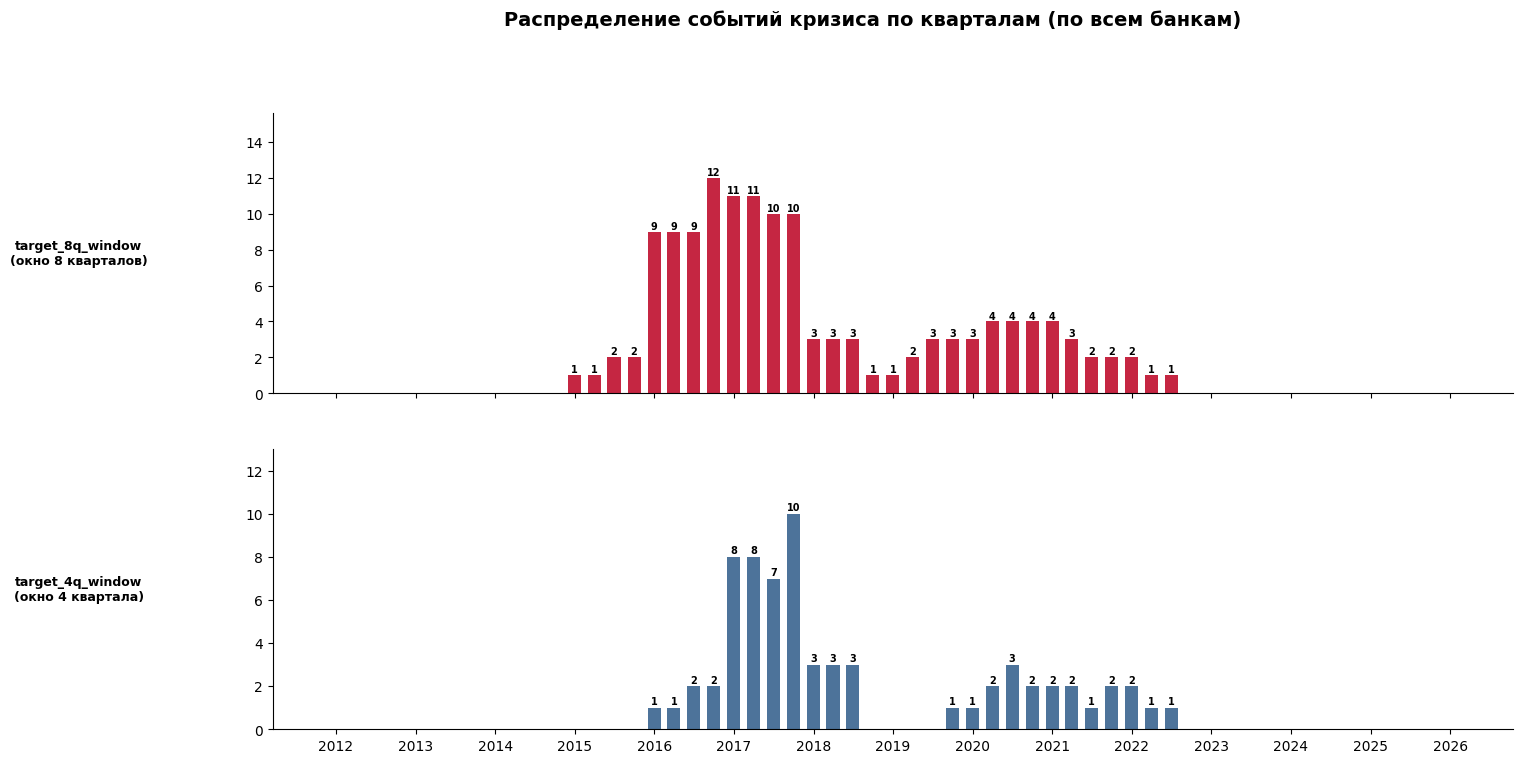

In [9]:
# Plot 1
targets = ['target_8q_window', 'target_4q_window', 'target_8q_point', 'target_4q_point']
agg = df.groupby('Quarter')[targets].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

info = [
    ('target_8q_window', 'target_8q_window\n(окно 8 кварталов)', '#BB0021'),
    ('target_4q_window', 'target_4q_window\n(окно 4 квартала)',  '#2E5B88'),
    # ('target_8q_point',  'target_8q_point\n(точка за 8 кв.)',    '#808180'),
    # ('target_4q_point',  'target_4q_point\n(точка за 4 кв.)',    'skyblue'),
    ]

for i, (col, label, color) in enumerate(info):
    ax = axes[i]
    ax.bar(agg['Quarter'], agg[col], width=60, color=color, alpha=0.85)
    ax.set_ylabel(label, fontsize=9, fontweight='bold',
                  rotation=0, labelpad=120, va='center')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for x, y in zip(agg['Quarter'], agg[col]):
        if y > 0:
            ax.text(x, y + 0.15, str(int(y)), ha='center', fontsize=7, fontweight='bold')
    ax.set_ylim(0, agg[col].max() * 1.3 if agg[col].max() > 0 else 1)

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Распределение событий кризиса по кварталам (по всем банкам)',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('eda_target_timeline.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

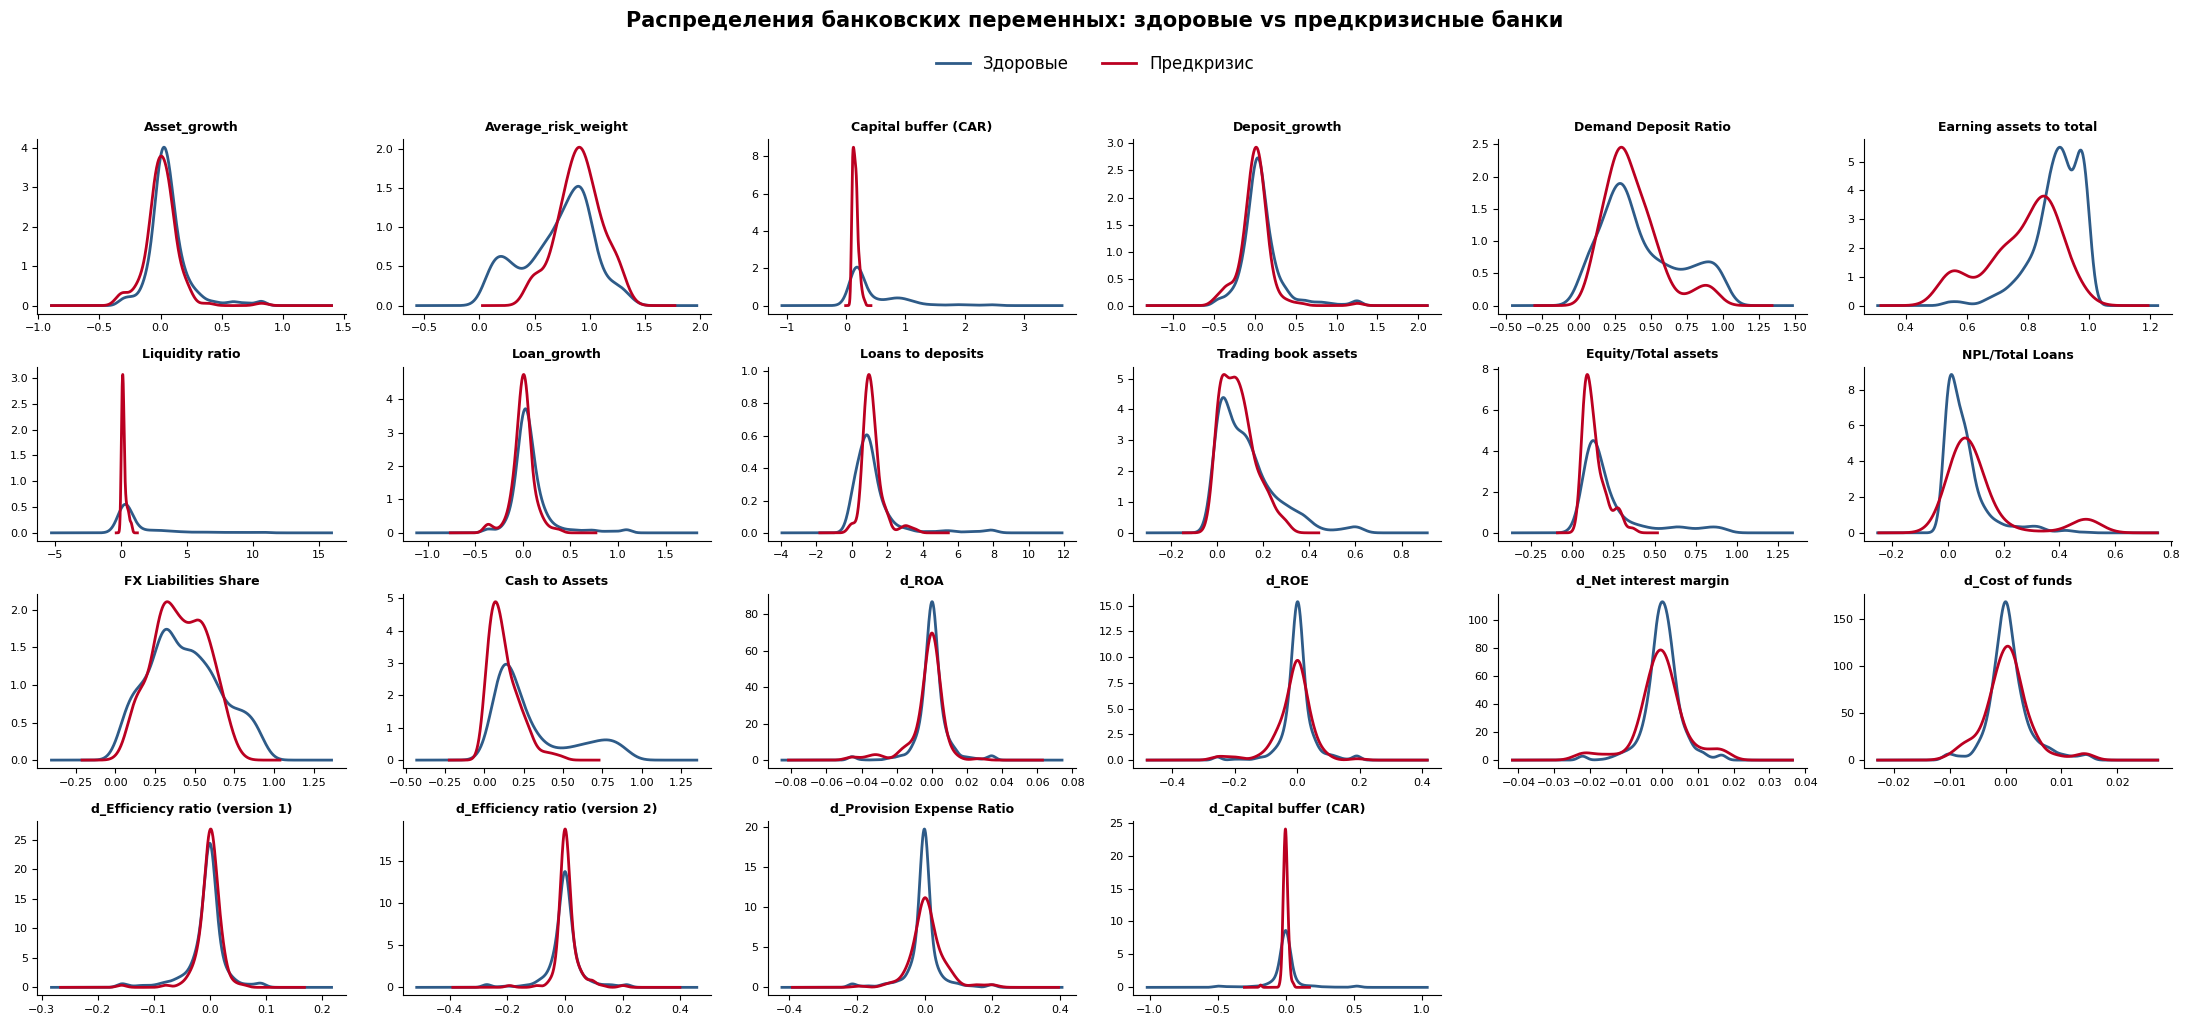

In [10]:
# Plot 2
bank_features = [c for c in df.columns if c not in [
    'BANK_ID', 'Quarter', 'target_8q_window', 'target_4q_window',
    'target_8q_point', 'target_4q_point',
    'rgdp_yoy', 'cpi_y', 'income', 'USD_KZT_qoq', 'USD_RUB_qoq'
]]

fig, axes = plt.subplots(4, 6, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(bank_features):
    ax = axes[i]
    df[df.target_8q_window == 0][col].plot.kde(ax=ax, color='#2E5B88', label='Здоровые', linewidth=2)
    df[df.target_8q_window == 1][col].plot.kde(ax=ax, color='#BB0021', label='Предкризис', linewidth=2)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8)

for j in range(len(bank_features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Распределения банковских переменных: здоровые vs предкризисные банки',
             fontsize=15, fontweight='bold', y=1.02)
fig.legend(['Здоровые', 'Предкризис'], loc='upper center',
           bbox_to_anchor=(0.5, 0.99), ncol=2, fontsize=12, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('eda_distributions.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

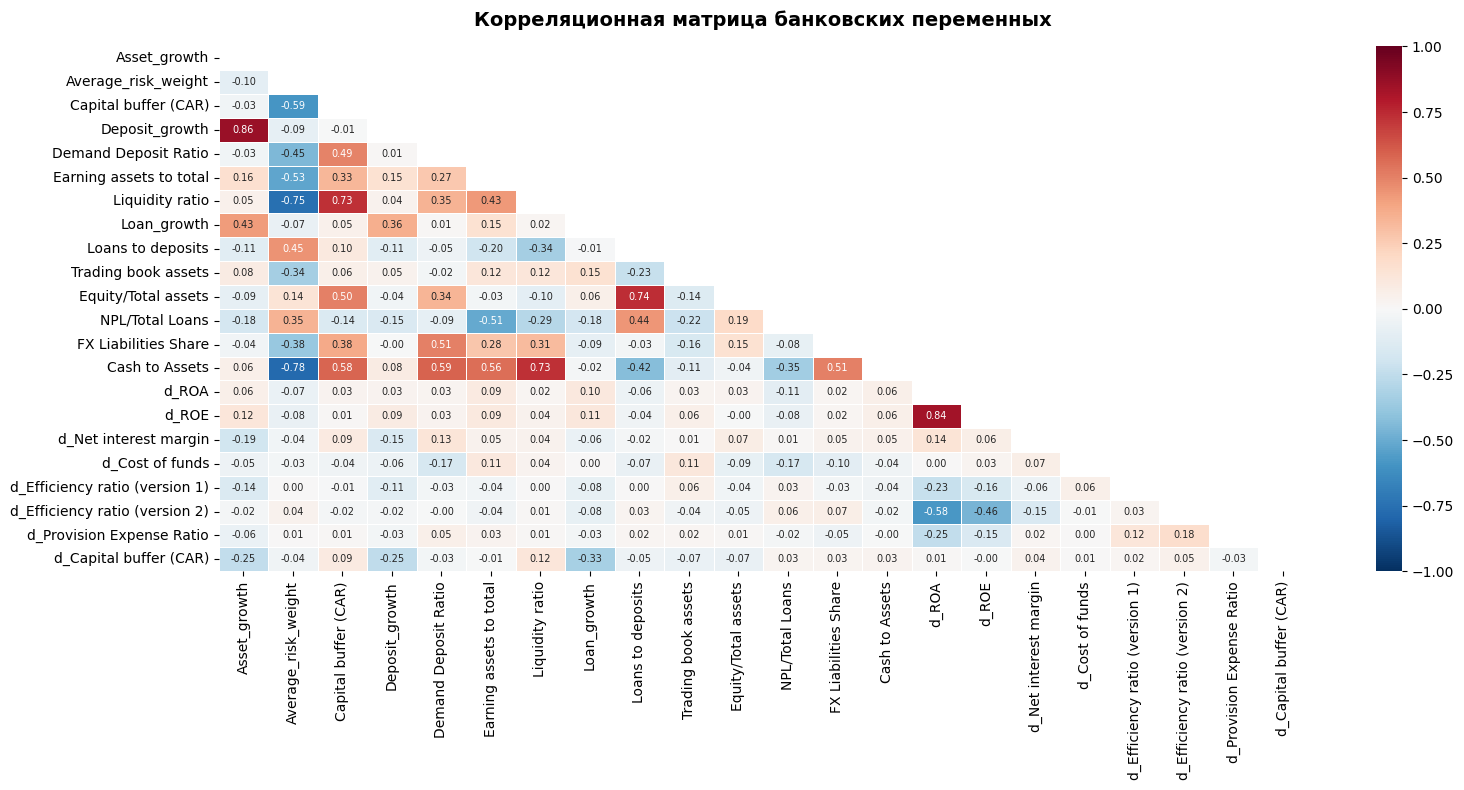

In [11]:
corr = df[bank_features].corr()

fig, ax = plt.subplots(figsize=(16, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 7}, linewidths=0.5)
ax.set_title('Корреляционная матрица банковских переменных',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
# plt.savefig('eda_corr.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()